# Catalogues over time

## Formalities

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from gaianir_open_clusters import plots

plots.setup_matplotlib(no_log=True, latex=False)

## OC catalogues

In [2]:
numbers_over_time = {
    "Messier": [1781, 28, "V"],  # see http://spider.seds.org/ngc/ngc.html
    "W. Herschel": [1786, 79, "V"],
    " W. Herschel": [1789, 168, "V"],
    "  W. Herschel": [1802, 197, "V"],
    "GC / J. Herschel": [1864, (712 + 197) / 2, "V"],
    "NGC / Dreyer": [1887, 712, "V"],  # see above, also includes messier objects
    "IC II / Dreyer": [1908, 723, "V"],  # see above, also includes messier objects
    "Alter+": [1965, 945, "V"],  # http://adsabs.harvard.edu/full/1966BAICz..17...33R
    "Lyngå+": [1982, 1151, "V"],
    "Mermilliod+": [
        1995,
        1200,
        "V",
    ],  # https://ui.adsabs.harvard.edu/abs/1995ASSL..203..127M/abstract
    "Dias+": [2002, 1537, "V+H"],
    "Kharchenko+": [2013, 2267 + 132, "V+IR+H"],
    "Cantat-Gaudin+": [2018, 1229, "G"],
    "Bica+": [2019, 3563, "V+IR"],
    "Cantat-Gaudin+ ": [2020, 1867, "G"],
    "Dias+ ": [2021, 1537, "G"],
    "Hunt+": [2023, 7033, "G"],
    "Hunt+ ": [2024, 5647, "G"],
}

marker_settings = {
    "V": "ko",
    "V+H": "ks",
    "V+IR": "ro",
    "V+IR+H": "rs",
    "G": "bs",
}

## 

## Presentation edition

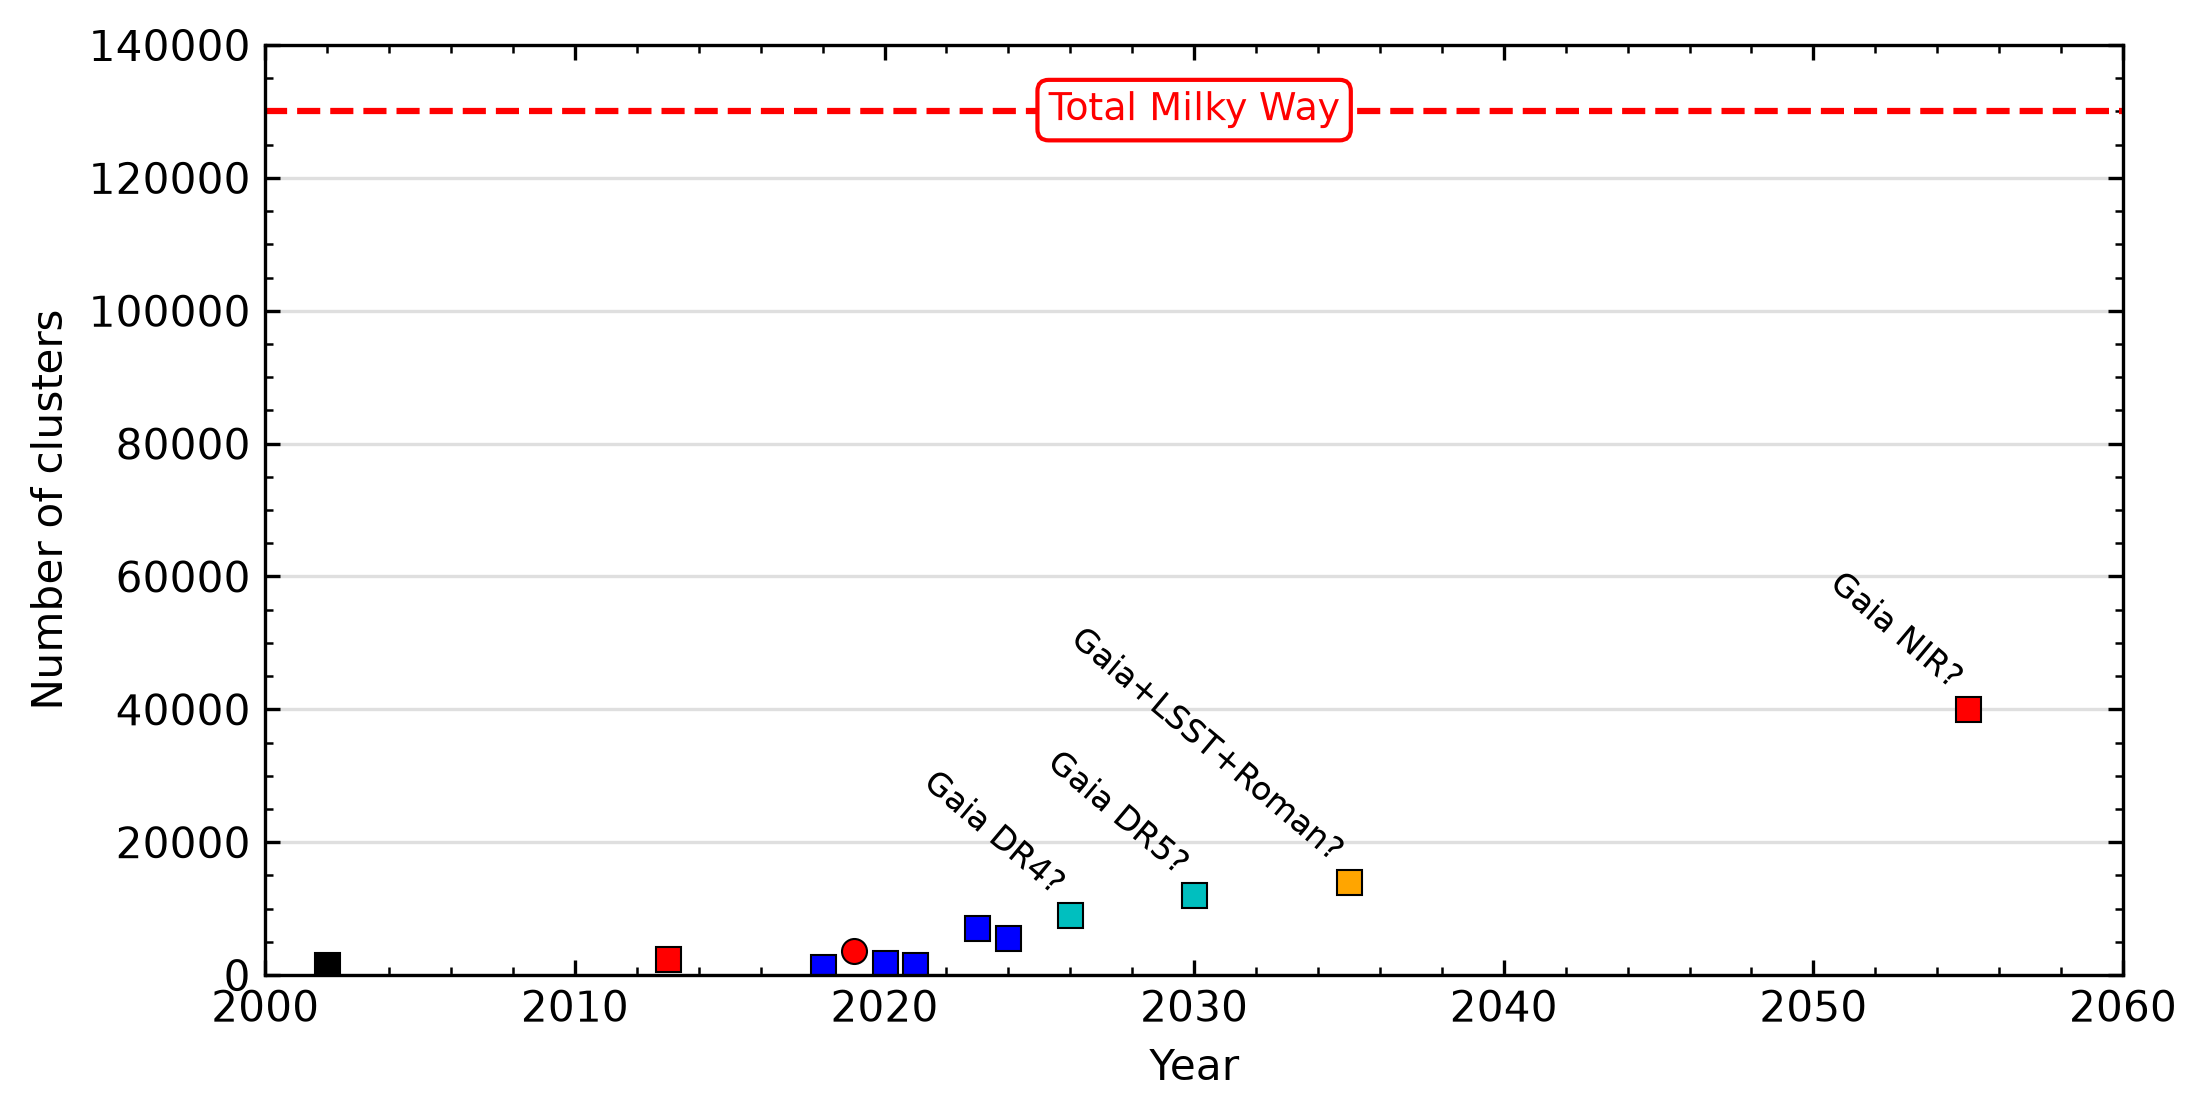

In [8]:
text_settings = {
    "va": "bottom",
    "ha": "right",
    "fontsize": 8,
    "rotation": -40,
}

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(WIDTH, 3), sharey=True)
fig, ax = plt.subplots(1, 1, figsize=(plots.TEXTWIDTH, plots.TEXTWIDTH * 0.5), dpi=300)
ax.set(
    xlim=(1750, 2000),
    yscale="log",
    ylabel="Number of clusters",
    xlabel="Year",
    ylim=(10, 3000),
)
ax.minorticks_on()
ax.grid(axis="y", alpha=0.4)

et_al_text = ax.text(
    0.05,
    -0.13,
    "+ implies et al.",
    ha="left",
    va="top",
    fontsize=8,
    transform=ax.transAxes,
)

# Cycle over all the catalogues, plotting and labelling them
point_labels = []
for a_name in numbers_over_time.keys():
    year, number, obs_type = numbers_over_time[a_name]
    marker = marker_settings[obs_type]

    if "J. Herschel" not in a_name:
        ax.plot(year, number, marker, mew=0.5, mec="k")
    else:
        ax.errorbar(
            year, number, fmt=marker, mew=0.5, mec="k", yerr=250, capsize=3, lw=1.0
        )

    # Add text
    settings = text_settings.copy()

    # Extra move for TCG 18
    if year == 2018:
        number *= 0.85

    if obs_type == "G":
        settings = {
            "va": "bottom",
            "ha": "left",
            "fontsize": text_settings["fontsize"],
            "rotation": 45,
        }
        year += 3
        number *= 0.975
    else:
        year -= 2
        number *= 1.025

    point_labels.append(ax.text(year, number, a_name, **settings))

    # if "Mermilliod" in a_name:
    #     fig.savefig(
    #         plots.FIGS_PRES / "catalogues_over_time_early.png", dpi=300
    #     )


# Legend time
form = dict(mew=0.5, mec="k")
legend = ax.legend(
    handles=[
        Line2D([0], [0], color="k", marker="o", lw=0, label="Visual-only", **form),
        Line2D([0], [0], color="k", marker="s", lw=0, label="Visual+Hipparcos", **form),
        Line2D([0], [0], color="r", marker="o", lw=0, label="Visual+IR", **form),
        Line2D(
            [0], [0], color="r", marker="s", lw=0, label="Visual+IR+Hipparcos", **form
        ),
        Line2D([0], [0], color="b", marker="s", lw=0, label="Gaia", **form),
    ],
    loc="lower center",
    edgecolor="k",
    framealpha=1.0,
    fontsize=8,
)

# legend.set_visible(False)
ax.set(xlim=(1750, 2055), ylim=(10, 20000))
fig.savefig(plots.FIGS_PRES / "catalogues_over_time.png", dpi=300)


# Add lines
x = np.linspace(1775, 1800)
y = np.exp(0.12 * (x - x[0]) + 3)
point_labels.append(ax.plot(x, y, "-", color="purple", lw=2.5, alpha=0.75)[0])

x = np.linspace(2010, 2033)
y = np.exp(0.12 * (x - x[0]) + 6.8)
point_labels.append(ax.plot(x, y, "-", color="purple", lw=2.5, alpha=0.75)[0])

point_labels.append(
    ax.text(
        1790,
        1250,
        "ERA 1:\nWidespread\nreflecting\ntelescopes",
        ha="center",
        color="purple",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )
)

point_labels.append(
    ax.text(
        2020,
        750,
        "ERA 2:\nThe CCD and\nspace-based\nastrometry",
        ha="center",
        color="purple",
        va="top",
        fontsize=10,
        fontweight="bold",
    )
)

fig.savefig(plots.FIGS_PRES / "catalogues_over_time_eras.png", dpi=300)

xlim = ax.get_xlim()
ax.plot((xlim[0], xlim[1] + 100), [1.3e5] * 2, "r--")
ax.text(
    # 1900,
    # 1.3e5,
    0.5,
    0.93,
    "Total Milky Way",
    color="red",
    ha="center",
    va="center",
    bbox=dict(facecolor="w", edgecolor="r", boxstyle="round"),
    fontsize=9,
    transform=ax.transAxes,
)
legend.set_visible(False)
ax.set(xlim=xlim, ylim=[10, 3e5])

# fig.savefig(
#     plots.FIGS_PRES / "catalogues_over_time_total.png", dpi=300, bbox_inches="tight"
# )

ax.set(yscale="linear", ylim=(0, 1.4e5))
ax.minorticks_on()
# ax.grid(which="minor", axis="y", alpha=0.25)

for label in point_labels:
    label.set_visible(False)
et_al_text.set_visible(False)

fig.savefig(plots.FIGS_PRES / "catalogues_over_time_total_linear.png", dpi=300)

text_settings["fontsize"] = 8
# text_settings["fontweight"] = "bold"

ax.plot(2026, 9000, "cs", mew=0.5, mec="k")
ax.text(2026, 11000, "Gaia DR4?", **text_settings)

ax.plot(2030, 12000, "cs", mew=0.5, mec="k")
ax.text(2030, 14000, "Gaia DR5?", **text_settings)

ax.plot(2035, 14000, "s", color="orange", mew=0.5, mec="k")
ax.text(2035, 16000, "Gaia+LSST+Roman?", **text_settings)

ax.plot(2055, 40000, "rs", mew=0.5, mec="k")
ax.text(2055, 42000, "Gaia NIR?", **text_settings)

ax.set(xlim=(2000, 2060))

fig.savefig(plots.FIGS_PRES / "catalogues_over_time_total_extrapolated.png", dpi=300)